# Exploratory Data Analysis (EDA)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("clean_data.csv")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_flag_suspicious,car_age,is_electric
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6,MANUAL,rear wheel drive,2,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26.0,19,3916,46135,False,6,False
1,BMW,1 Series,2011,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,"Luxury,Performance",Compact,Convertible,28.0,19,3916,40650,False,6,False
2,BMW,1 Series,2011,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,"Luxury,High-Performance",Compact,Coupe,28.0,20,3916,36350,False,6,False
3,BMW,1 Series,2011,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,"Luxury,Performance",Compact,Coupe,28.0,18,3916,29450,False,6,False
4,BMW,1 Series,2011,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Luxury,Compact,Convertible,28.0,18,3916,34500,False,6,False


# Descriptive Statistics using Numerical Columns

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols]

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp,car_age
0,2011,335.0,6,2,26.0,19,3916,46135,6
1,2011,300.0,6,2,28.0,19,3916,40650,6
2,2011,300.0,6,2,28.0,20,3916,36350,6
3,2011,230.0,6,2,28.0,18,3916,29450,6
4,2011,230.0,6,2,28.0,18,3916,34500,6
...,...,...,...,...,...,...,...,...,...
11194,2012,300.0,6,4,23.0,16,204,46120,5
11195,2012,300.0,6,4,23.0,16,204,56670,5
11196,2012,300.0,6,4,23.0,16,204,50620,5
11197,2013,300.0,6,4,23.0,16,204,50920,4


In [20]:
# Median, Mean and Standard Deviation

keyfindings = pd.DataFrame({
    'Median': df[numeric_cols].median(),
    'Mean': df[numeric_cols].mean(),
    'Standard Deviation':df[numeric_cols].std()
})

keyfindings

,Median,Mean,Standard Deviation
year,2015.0,2010.714528,7.228211
engine_hp,239.0,253.227788,109.865570
engine_cylinders,6.0,5.661488,1.802632
number_of_doors,4.0,3.454237,0.872896
highway_mpg,25.0,26.581838,8.427817
city_mpg,18.0,19.731851,9.177555
popularity,1385.0,1558.483347,1445.668872
msrp,30675.0,41925.927136,61535.047817
car_age,2.0,6.285472,7.228211


So, what can we conclude from these statistics?

* The mean and median values show that most vehicles have around 4 doors and 6 engine cylinders.

* Engine horsepower has a relatively large spread, with a mean of 253.23 HP and a standard deviation of 109.87, indicating considerable variation between vehicles.

 * MSRP has the largest variation, with a mean of 41,925,93 compared with a median of 30,675 and a standard deviation of 61,535.05. This large difference between the mean and median suggests that some expensive vehicles are increasing the average price.

 * Popularity also has a large standard deviation, indicating substantial differences in popularity among vehicles.

 Overall, variables such as MSRP, popularity, and engine horsepower show the greatest variation.

# Insights & Patterns

Now we may have some questions regarding the insights and patterns.
For example, What does the distribution of car prices look like?

## Correlation Analysis

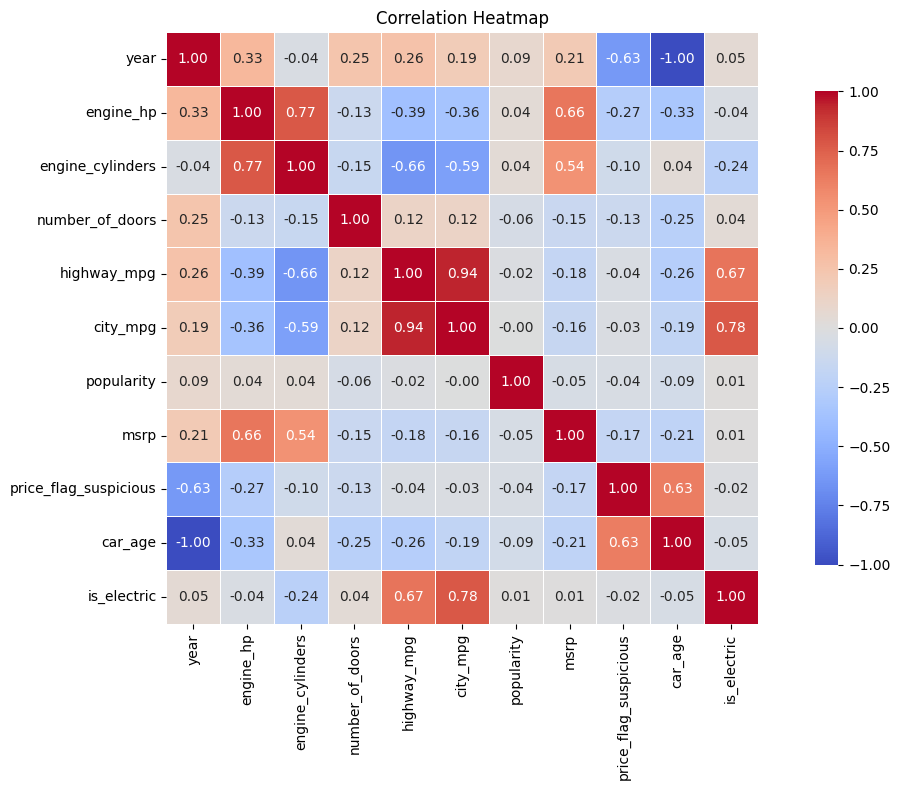

In [46]:
corr_matrix=df.corr(method='pearson',numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          
    fmt='.2f',           
    cmap='coolwarm',
    center=0,              
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Relationships

- There is a **strong positive relationship** between `highway_mpg` and `city_mpg`, meaning that cars with higher highway MPG tend to also have higher city MPG.

- There is a **strong positive relationship** between `city_mpg` and `is_electric`, meaning that electric cars tend to have much higher city MPG.

- There is a **strong positive relationship** between `engine_hp` and `engine_cylinders`, meaning that cars with more cylinders tend to have higher horsepower.

- There is a **positive relationship** between `highway_mpg` and `is_electric`, meaning that electric cars tend to have higher highway MPG.

- There is a **positive relationship** between `engine_hp` and `msrp`, meaning that cars with higher horsepower tend to have higher price.

- There is a **positive relationship** between `price_flag_suspicious` and `car_age`, meaning that older cars tend to be more likely flagged as having a suspicious price.

- There is a **positive relationship** between `engine_cylinders` and `msrp`, meaning that cars with more cylinders tend to have higher price.

- There is a **perfect negative relationship** between `year` and `car_age`, meaning that newer cars tend to have a lower car age (this is expected since `car_age` is directly derived from `year`).

- There is a **negative relationship** between `engine_cylinders` and `highway_mpg`, meaning that cars with more cylinders tend to have lower fuel efficiency on the highway.

- There is a **negative relationship** between `engine_cylinders` and `city_mpg`, meaning that cars with more cylinders tend to have lower fuel efficiency in the city.


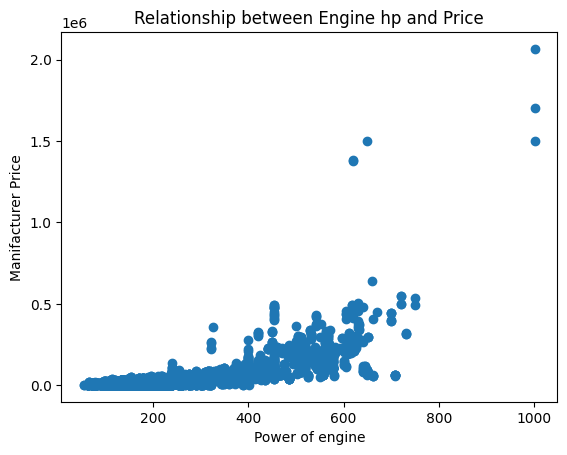

In [ ]:
plt.scatter(df['engine_hp'],df['msrp'])
plt.title('Relationship between Engine hp and Price')
plt.xlabel('Power of engine')
plt.ylabel('Manifacturer Price')
plt.show()

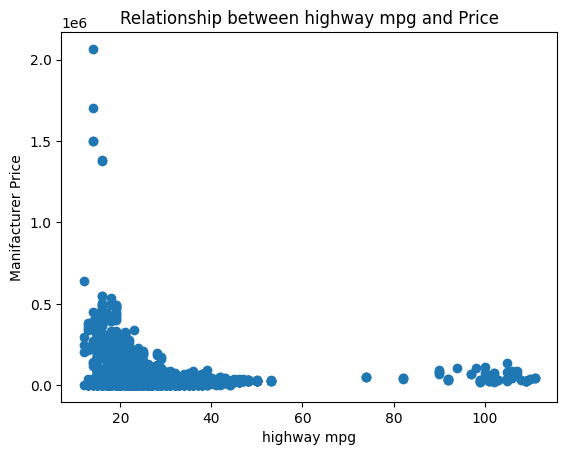

In [41]:
plt.scatter(df['highway_mpg'],df['msrp'])
plt.title('Relationship between highway mpg and Price')
plt.xlabel('highway mpg')
plt.ylabel('Manifacturer Price')
plt.show()

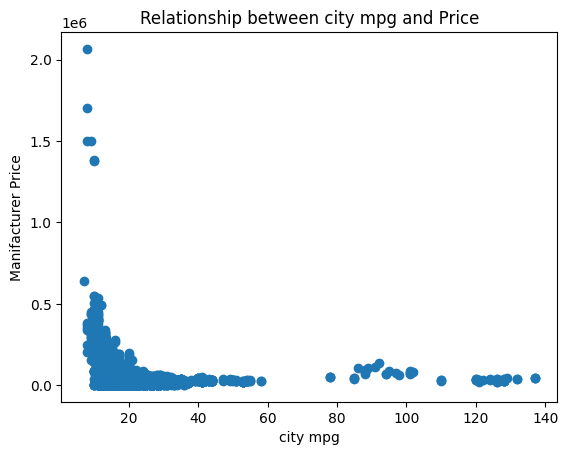

In [40]:
plt.scatter(df['city_mpg'],df['msrp'])
plt.title('Relationship between city mpg and Price')
plt.xlabel('city mpg')
plt.ylabel('Manifacturer Price')
plt.show()

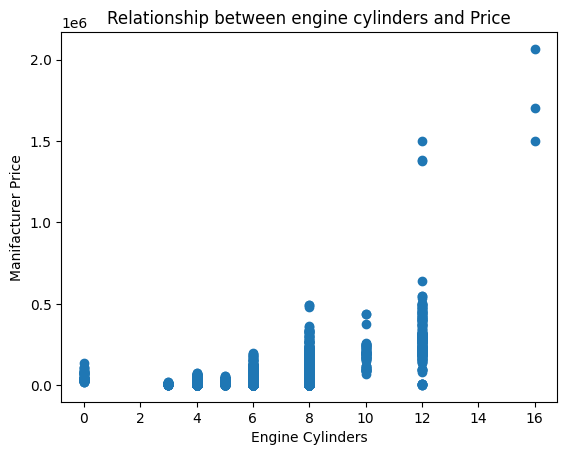

In [39]:
plt.scatter(df['engine_cylinders'],df['msrp'])
plt.title('Relationship between engine cylinders and Price')
plt.xlabel('Engine Cylinders')
plt.ylabel('Manifacturer Price')
plt.show()

## Hypothesis Testing